# Hyades Force Analysis

Fetch Hyades members from two Vizier catalogs and compute their galactocentric $(x, y, z)$ positions.

Catalogs:
- **J/A+A/623/A35** — Reino et al. (2018), *A 3D view of the Hyades stellar population.* Provides RA/Dec/parallax directly.
- **J/A+A/621/L2** — Meingast & Alves (2019), *Hyades tidal tails revealed by Gaia DR2.* The Vizier table only stores RA/Dec/Gmag plus the Gaia DR2 `Source` ID, so we cross-match those IDs against `gaiadr2.gaia_source` to recover parallax.

We convert (RA, Dec, $1/\varpi$) to ICRS Cartesian, then to galactocentric coordinates using `astropy.coordinates.Galactocentric` (origin at the Galactic center, Sun at $x \approx -8.122$ kpc).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric
from astropy.table import vstack
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## 1. Query Vizier

By default Vizier returns only a curated subset of columns. We pass `columns=["**"]` to get every column (so `Plx`, `Source`, etc. are included) and `row_limit=-1` to disable the 50-row cap.

In [2]:
v = Vizier(columns=["**"], row_limit=-1)
reino_tab = v.get_catalogs("J/A+A/623/A35")[0]
meingast_tab = v.get_catalogs("J/A+A/621/L2")[0]

print(f"Reino+18:   {len(reino_tab)} rows, cols={reino_tab.colnames}")
print(f"Meingast19: {len(meingast_tab)} rows, cols={meingast_tab.colnames}")

Reino+18:   1764 rows, cols=['recno', 'ID', 'RAICRS', 'DEICRS', 'pmRA*', 'pmDE', 'Plx', 'Gmag', 'bx', 'by', 'bz', 'Dist', 'c', 'Mass', 'RV', '_RA.icrs', '_DE.icrs']
Meingast19: 1316 rows, cols=['recno', 'Source', 'RAICRS', 'DEICRS', 'Gmag', 'Member', 'Comment', 'Simbad', '_RA.icrs', '_DE.icrs']


## 2. Build SkyCoords

Reino+18 carries parallax directly. Meingast+19 does not, so we send its Gaia DR2 source IDs to the Gaia archive in chunks (the `IN (...)` clause has a length limit) and stitch the results back together.

In [3]:
def skycoord_from_radec_plx(ra_deg, dec_deg, plx_mas):
    """Build an ICRS SkyCoord, dropping rows with non-positive / non-finite parallax."""
    ra = np.asarray(ra_deg, dtype=float)
    dec = np.asarray(dec_deg, dtype=float)
    plx = np.asarray(plx_mas, dtype=float)
    good = np.isfinite(ra) & np.isfinite(dec) & np.isfinite(plx) & (plx > 0)
    distance_pc = 1000.0 / plx[good]
    return SkyCoord(
        ra=ra[good] * u.deg,
        dec=dec[good] * u.deg,
        distance=distance_pc * u.pc,
        frame="icrs",
    )


core = skycoord_from_radec_plx(reino_tab["RAICRS"], reino_tab["DEICRS"], reino_tab["Plx"])
print(f"Reino+18 core stars (positive parallax): {len(core)}")

Reino+18 core stars (positive parallax): 1764


In [4]:
def fetch_gaia_dr2_parallax(source_ids, chunk=500):
    """Query gaiadr2.gaia_source for ra/dec/parallax of the given source IDs."""
    source_ids = [int(s) for s in source_ids]
    pieces = []
    for i in range(0, len(source_ids), chunk):
        ids_str = ",".join(str(s) for s in source_ids[i:i + chunk])
        query = (
            "SELECT source_id, ra, dec, parallax "
            "FROM gaiadr2.gaia_source "
            f"WHERE source_id IN ({ids_str})"
        )
        pieces.append(Gaia.launch_job(query).get_results())
    return vstack(pieces)


gaia_tails = fetch_gaia_dr2_parallax(meingast_tab["Source"])
print(f"Gaia DR2 rows returned for tails: {len(gaia_tails)} / {len(meingast_tab)}")

tails = skycoord_from_radec_plx(gaia_tails["ra"], gaia_tails["dec"], gaia_tails["parallax"])
print(f"Tails stars with positive parallax: {len(tails)}")

Gaia DR2 rows returned for tails: 1316 / 1316
Tails stars with positive parallax: 1316


## 3. Transform to galactocentric Cartesian

`Galactocentric` puts the origin at the Galactic center, the Sun at $x \approx -8.122$ kpc, and the disk in the $x$–$y$ plane.

In [5]:
gc_frame = Galactocentric()

core_gc = core.transform_to(gc_frame)
tails_gc = tails.transform_to(gc_frame)

core_xyz = np.array([core_gc.x.to(u.kpc).value,
                     core_gc.y.to(u.kpc).value,
                     core_gc.z.to(u.kpc).value])
tails_xyz = np.array([tails_gc.x.to(u.kpc).value,
                      tails_gc.y.to(u.kpc).value,
                      tails_gc.z.to(u.kpc).value])

print(f"Core   centroid (kpc): x={core_xyz[0].mean():.3f}, y={core_xyz[1].mean():.3f}, z={core_xyz[2].mean():.3f}")
print(f"Tails  centroid (kpc): x={tails_xyz[0].mean():.3f}, y={tails_xyz[1].mean():.3f}, z={tails_xyz[2].mean():.3f}")

Core   centroid (kpc): x=-8.174, y=-0.007, z=0.010
Tails  centroid (kpc): x=-8.144, y=0.007, z=0.007


## 4. Plot

Three orthogonal projections plus a 3D view. The Sun sits at $(-8.122, 0, 0.0208)$ kpc for reference.

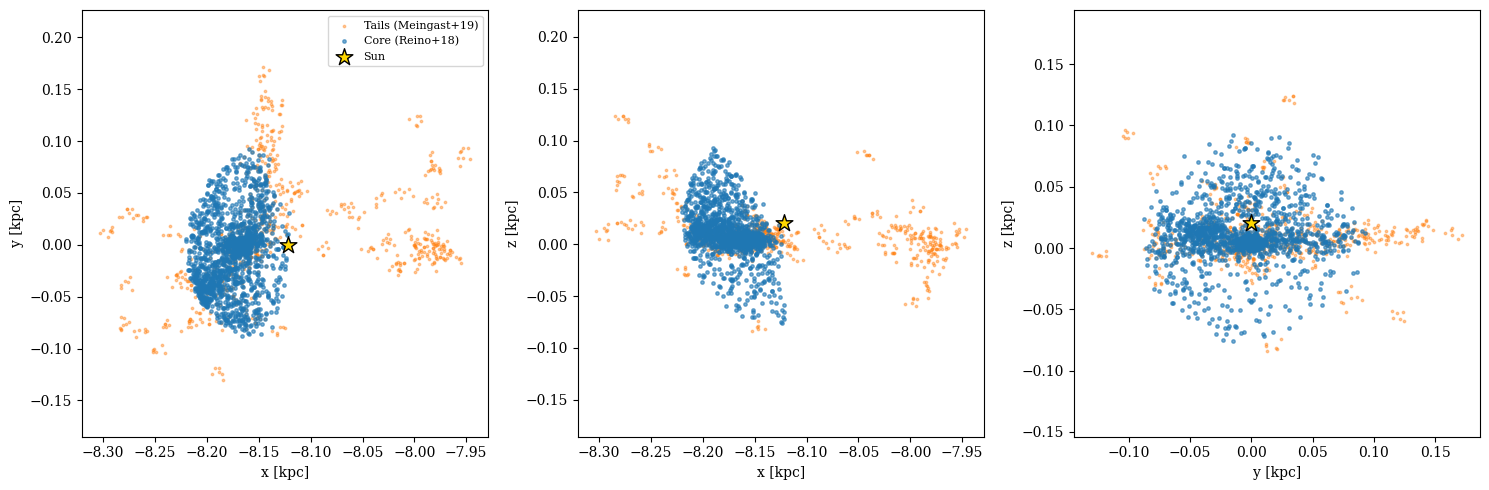

In [6]:
sun = Galactocentric().galcen_distance.to(u.kpc).value
sun_xyz = (-sun, 0.0, Galactocentric().z_sun.to(u.kpc).value)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
projections = [((0, 1), ("x [kpc]", "y [kpc]")),
               ((0, 2), ("x [kpc]", "z [kpc]")),
               ((1, 2), ("y [kpc]", "z [kpc]"))]
for ax, ((i, j), (xl, yl)) in zip(axes, projections):
    ax.scatter(tails_xyz[i], tails_xyz[j], s=3, alpha=0.4, label="Tails (Meingast+19)", color="C1")
    ax.scatter(core_xyz[i], core_xyz[j], s=6, alpha=0.6, label="Core (Reino+18)", color="C0")
    ax.scatter(sun_xyz[i], sun_xyz[j], marker="*", s=160, color="gold", edgecolor="k", label="Sun")
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_aspect("equal", adjustable="datalim")
axes[0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

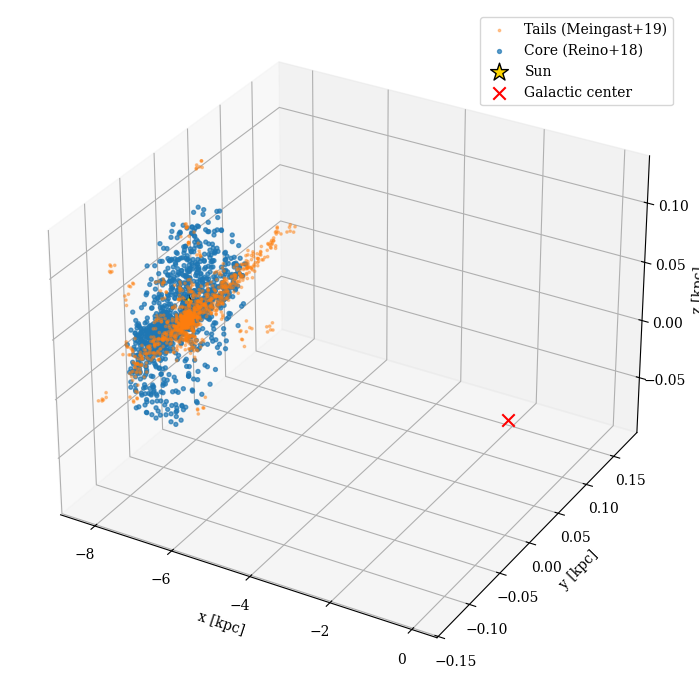

In [7]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*tails_xyz, s=3, alpha=0.4, label="Tails (Meingast+19)", color="C1")
ax.scatter(*core_xyz, s=8, alpha=0.7, label="Core (Reino+18)", color="C0")
ax.scatter(*sun_xyz, marker="*", s=180, color="gold", edgecolor="k", label="Sun")
ax.scatter(0, 0, 0, marker="x", s=80, color="red", label="Galactic center")
ax.set_xlabel("x [kpc]"); ax.set_ylabel("y [kpc]"); ax.set_zlabel("z [kpc]")
ax.legend()
plt.tight_layout()
plt.show()

# Accelerations

In [63]:
from ezfalcon.dynamics import FalcONGravity, ExternalGalpyPotential
from galpy.potential import MWPotential2014

selfgrav = FalcONGravity(eps=0.01, theta=0.5)
mw = ExternalGalpyPotential(MWPotential2014)
netforce = selfgrav + mw

In [64]:
netforce

In [65]:
tail_self_acc = selfgrav.acc(tails_xyz.T, np.ones(tails_xyz.shape[1]))
core_self_acc = selfgrav.acc(core_xyz.T, np.ones(core_xyz.shape[1]))

tail_ext_acc = mw.acc(tails_xyz.T, 0.0)
core_ext_acc = mw.acc(core_xyz.T, 0.0)

tail_net_acc = netforce.acc(tails_xyz.T, np.ones(tails_xyz.shape[1]), 0.0)
core_net_acc = netforce.acc(core_xyz.T, np.ones(core_xyz.shape[1]), 0.0)

In [66]:
tail_self_acc + tail_ext_acc - tail_net_acc

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], shape=(1316, 3))

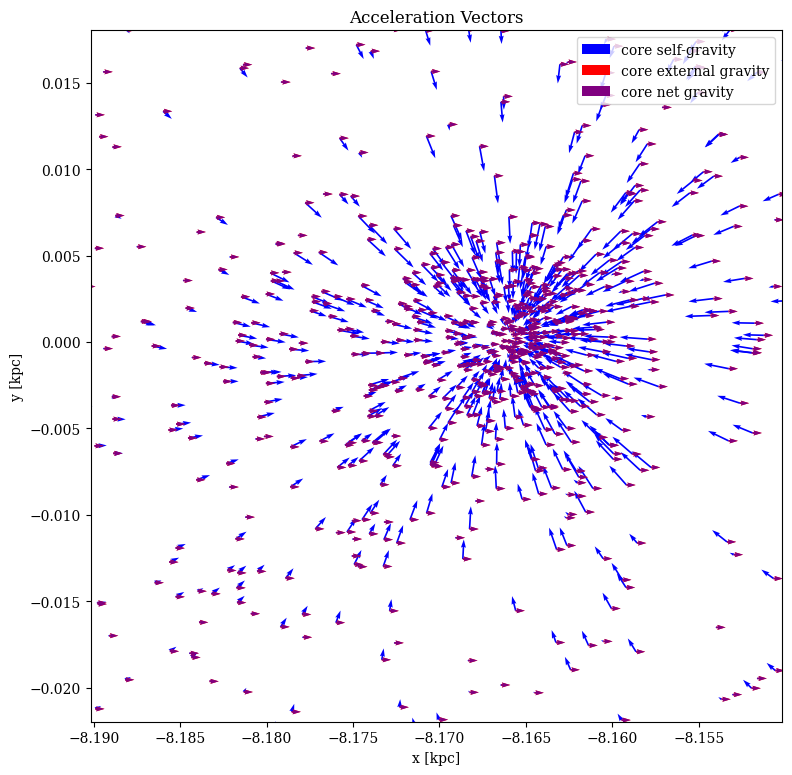

In [67]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(core_xyz.T[:, 0], core_xyz.T[:, 1], core_self_acc[:, 0], core_self_acc[:, 1], alpha=1, color='b', label='core self-gravity')
ax.quiver(core_xyz.T[:, 0], core_xyz.T[:, 1], core_ext_acc[:, 0], core_ext_acc[:, 1], alpha=1, color='r', label='core external gravity')
ax.quiver(core_xyz.T[:, 0], core_xyz.T[:, 1], core_net_acc[:, 0], core_net_acc[:, 1], alpha=1, color='purple', label='core net gravity')
center = np.median(core_xyz, axis=1)
ax.set_xlim(center[0] - 0.02, center[0] + 0.02)
ax.set_ylim(center[1] - 0.02, center[1] + 0.02)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_title('Acceleration Vectors')
ax.set_aspect('equal')
plt.tight_layout()
plt.legend()
plt.show()

In [43]:
selfgrav.acc(np.array([center]) + np.array([10, 0, 0]).T,  1.)

array([[0., 0., 0.]])

# Bound/Unbound

In [13]:
# Coming soon...